# *Proyecto Semestral IMT2200*

## *Entrega Final repositorio*

**Alumnos:** Lucas Chicao, Ninoska Cid e Isidora Gomez

**Profesor:** Rodrigo A. Carrasco

---

# *Introducción*

Este proyecto investiga las desigualdades educativas en Chile mediante el análisis cuantitativo de resultados de la PAES (Prueba de Acceso a la Educación Superior) durante los años 2023-2025.
Utilizando técnicas de análisis estadístico inferencial y machine learning, cuantificamos las brechas entre estudiantes de colegios municipales, particulares subvencionados y particulares pagados.

## *Objetivos*

El objetivo de esta investigación es cuantificar las diferencias en rendimiento académico entre distintos tipos de establecimientos y evaluar la magnitud de las desigualdades educativas, identificando a su vez los factores que influyen en el acceso a universidades tradicionales, todo esto con el fin de proporcionar evidencia para políticas públicas basadas en datos.

---

# *Analisis de Datos 2024*
Para el analisis de los datos se necesitara descomprimir los datos de forma manual y guardarlos en una carpeta que se llama 'Data_2024'

In [4]:
#LIBRERIAs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

In [10]:
#cargar datos
base_path = os.path.dirname(os.getcwd()) 

file_path1 = os.path.join(base_path, 'Resultado proyecto' ,'Datos_2024','Datos_2024', 'CSV_Datos_2024.csv')
file_path1



df_2024 = pd.read_csv(file_path1, encoding="utf-8")
df_2024

C:\Users\lchicao\AppData\Local\Temp\ipykernel_125472\1498620399.py:9: DtypeWarning: Columns (7,18,19,37,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2024 = pd.read_csv(file_path1, encoding="utf-8")


,Unnamed: 0,ID_aux,ANYO_PROCESO,FECHA_NACIMIENTO,RBD_x,COD_ENS_x,REGIMEN,RAMA_EDUCACIONAL_x,GRUPO_DEPENDENCIA_x,ANYO_EGRESO,...,MATE1_REG_ANTERIOR,MATE2_REG_ANTERIOR,HCSOC_REG_ANTERIOR,CIEN_REG_ANTERIOR,MODULO_REG_ANTERIOR,CLEC_INV_ANTERIOR,MATE_INV_ANTERIOR,HCSOC_INV_ANTERIOR,CIEN_INV_ANTERIOR,MODULO_INV_ANTERIOR
0,0,id_5846558574617,2024,12006,1.0,510.0,3.0,T2,4.0,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,id_5846558574617,2024,12006,1.0,510.0,3.0,T2,4.0,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,id_5846558574617,2024,12006,1.0,510.0,3.0,T2,4.0,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,id_5846558574617,2024,12006,1.0,510.0,3.0,T2,4.0,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,id_5846558574617,2024,12006,1.0,510.0,3.0,T2,4.0,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1100216,1100216,id_0996509579630,2024,22006,NaN,NaN,NaN,NaN,NaN,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1100217,1100217,id_0996509579630,2024,22006,NaN,NaN,NaN,NaN,NaN,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1100218,1100218,id_769579645727,2024,92004,NaN,NaN,NaN,NaN,NaN,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1100219,1100219,id_769579645727,2024,92004,NaN,NaN,NaN,NaN,NaN,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_2024[df_2024.duplicated()]

,Unnamed: 0,ID_aux,ANYO_PROCESO,FECHA_NACIMIENTO,RBD_x,COD_ENS_x,REGIMEN,RAMA_EDUCACIONAL_x,GRUPO_DEPENDENCIA_x,ANYO_EGRESO,...,MATE1_REG_ANTERIOR,MATE2_REG_ANTERIOR,HCSOC_REG_ANTERIOR,CIEN_REG_ANTERIOR,MODULO_REG_ANTERIOR,CLEC_INV_ANTERIOR,MATE_INV_ANTERIOR,HCSOC_INV_ANTERIOR,CIEN_INV_ANTERIOR,MODULO_INV_ANTERIOR


In [12]:
df_2024.isnull().sum()

Unnamed: 0                   0
ID_aux                       0
ANYO_PROCESO                 0
FECHA_NACIMIENTO             0
RBD_x                     5903
                        ...   
CLEC_INV_ANTERIOR      1066696
MATE_INV_ANTERIOR      1066696
HCSOC_INV_ANTERIOR     1066696
CIEN_INV_ANTERIOR      1066696
MODULO_INV_ANTERIOR    1077559
Length: 68, dtype: int64

Los datos null que aparecen en teoria no nos incomodaran para hacer el analisis.

Ademas, si se hace un dropna() nos puede generar mas problemas al eliminar columnas importantes.

### **1) ¿Qué tipo de colegio tiene mejores resultados en promedio?**

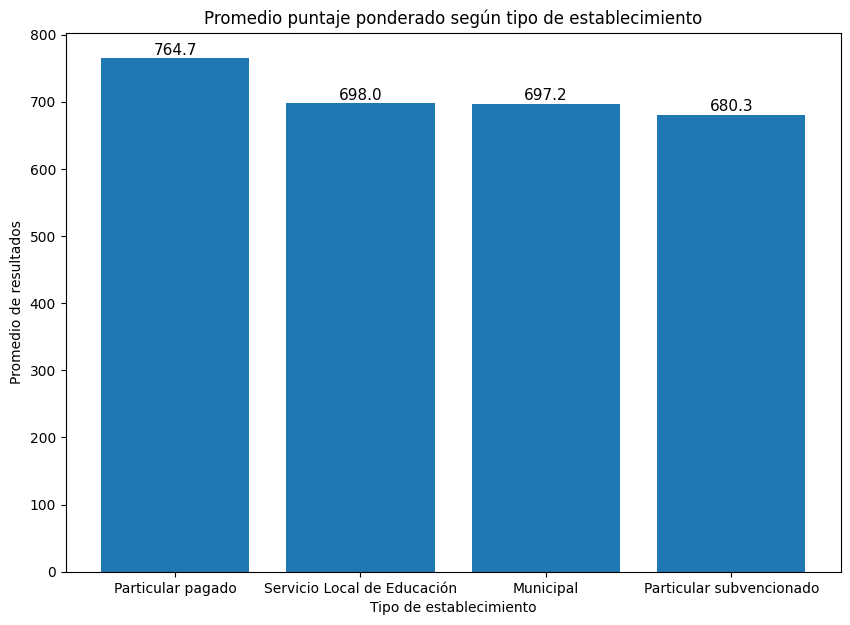

In [13]:
# usamos las columnas "PTJE_POND" y " GRUPO_DEPENDENCIA_x"
# esta ult. pq cuando unimos los archivos, esta columna venia de inscripcion, y
# GRUPO_DEPENDENCIA_y" proviene de rendicion, y esta base no esta hecha para describir el colegio
# asi tomamos la primera

# los datos de la columna "PTJE_POND" estan en formato object y los convierto a float para
# hacer operaciones matematicas pero los datos usan comas por lo que las remplazo con puntos
df_2024["PTJE_POND"] = df_2024["PTJE_POND"].astype(str).str.replace(",", ".", regex=False)
df_2024["PTJE_POND"] = pd.to_numeric(df_2024["PTJE_POND"], errors="coerce")
# errors="coerce" → si encuentra algo raro, lo pone como NaN para evitar errores

# creo un dict para cambiar asignarle el significado del dato que esta en grupo dependencia
mapa_dependencia = {1: "Particular pagado", 2: "Particular subvencionado",
                  3: "Municipal", 4: "Servicio Local de Educación"}

# creo una nueva columna donde guardo el tipo de colegio, pero como corresponde, no como un numero
df_2024["TIPO_COLEGIO"] = df_2024["GRUPO_DEPENDENCIA_x"].map(mapa_dependencia)

# ahora, agrupo los datos por tipo de colegio y calculo el promedio del ptje
resumen = (df_2024.groupby("TIPO_COLEGIO")["PTJE_POND"].mean().reset_index()
    .dropna(subset=["TIPO_COLEGIO"]).sort_values("PTJE_POND", ascending=False))
# tmb elimino filas donde los datos de TIPO_COLEGIO sea NaN
# y ordeno los puntajes de mayor a menor

# defino el tamaño del grafico (de barras)
plt.figure(figsize=(10, 7))
plt.bar(resumen["TIPO_COLEGIO"], resumen["PTJE_POND"])
# asigno el name del grafico y de los ejes (x, y)
plt.title("Promedio puntaje ponderado según tipo de establecimiento")
plt.xlabel("Tipo de establecimiento")
plt.ylabel("Promedio de resultados")
plt.xticks(rotation=0)

for i, valor in enumerate(resumen["PTJE_POND"]):
    plt.text(i, valor + 1, f"{valor:.1f}", ha='center', va='bottom', fontsize=11)
# esto lo uso para que cada barra tenga su valor numerico exacto encima, asi es mas facil de entender
plt.show() # muestro el grafico

respuesta grafico

### **2) ¿Qué tan grande es la brecha entre estos grupos?**

In [14]:
#codigo
print(764.7 - 680.3)

84.40000000000009


respuesta grafico

### **3) ¿Existe correlación entre el tipo de establecimiento y las probabilidades de acceso a universidades tradicionales?**

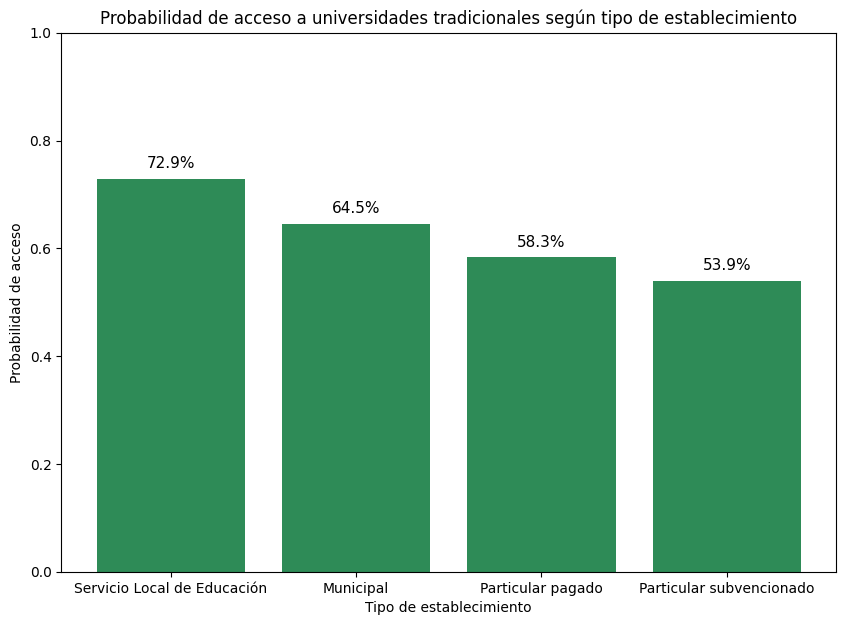

In [15]:
#codigo
# u tradicionales son las que pertenecen a CRUCH
# (Consejo de Rectoras y Rectores de las Universidades Chilenas)

# primero, creo un dict donde asigno la sigla de la u correspondiente
# esto es mas que nada para poder entender bien, junto con que ademas 
# solo se deben considerar las u que pertenecen a CRUCH
mapa_univ = {11: "UCH", # u de chile
    12: "PUC", # u catolica de chile
    13: "UDEC", # u de concepcion
    14: "PUCV", # u catolica de valpo
    15: "USM", # u federico santa maria
    16:"USACH", # u de santiago de chile
    17: "UACH", # u austral de chile
    18:"UCN", # u catolica del norte
    19: "UV", # u de valpo
    20: "UMCE", # u metropolitana de las ciencias de la educacion
    21: "UTEM", # u tecnologica metropolitana
    22: "UTA", # universidad de tarapaca
    23: "UNAP", # universidad arturo prat
    24: "UA", # u de antofagasta
    25: "ULS", # u de la serena
    26: "UPLA", # u de playa ancha
    27: "UDA", # u de atacama
    29: "UBB",# u del bio bio
    30: "UFRO", # u de la frontera
    32: "ULAGOS", # u de los lagos
    33: "UMAG", # u de magallanes
    34: "UTAL", # u de talca
    35: "UCM", # u catolica del maule
    36: "UCSC", # u catolica de la santisima concepcion
    37: "UCT", # u catolica de temuco
    38: "UDP", # u diego portales
    43: "UANDES", # u de los andes
    45: "UAH", # u alberto hurtado
    47: "UOH", # u de o'higgins
    48: "UAY" # u de aysén
}
# ahora, tomo el codigo de la u donde se matriculó y reviso si esta dentro del dict
# si es q esta queda como TRUE (1) y sino FALSE (0), y lo guardo en una nueva columna creada
df_2024["ACCESO_TRADICIONAL"] = df_2024["CODIGO_UNIV"].isin(mapa_univ.keys()).astype(int)

# ahora, calculo la probabilidad de acceso segun el tipo de colegio
# (el promedio es la probabilidad)
# y lo ordeno del tipo de colegio con mayor prob al que tiene menor
acceso = (df_2024.groupby("TIPO_COLEGIO")["ACCESO_TRADICIONAL"].mean().reset_index()
        .sort_values("ACCESO_TRADICIONAL", ascending=False))

# determino el tamaño del grafico y sus caracteristicas (de barras)
plt.figure(figsize=(10, 7))
plt.bar(acceso["TIPO_COLEGIO"], acceso["ACCESO_TRADICIONAL"], color="seagreen")
# asigno el titulo del grafico y de los ejes (x, y)
plt.title("Probabilidad de acceso a universidades tradicionales según tipo de establecimiento")
plt.xlabel("Tipo de establecimiento")
plt.ylabel("Probabilidad de acceso")
plt.ylim(0, 1)

for i, val in enumerate(acceso["ACCESO_TRADICIONAL"]):
    plt.text(i, val + 0.02, f"{val*100:.1f}%", ha='center', fontsize=11)
# esto es para mostar el % de prob de cada barra de cada tipo de colegio
plt.show() # muestro el grafico

# entre mas cerca al 1, mayor es el % de probabilidad de acceso

respuesta grafico

La diferencia tiene que analizarse de manera social y no tanto de manera estadistica, se tiene que considerar la localidad y la ubicacion de cada persona en el dataframe para poder sacar una explicacion a esta correlacion

Pero en general, si, hay una mayor probabilidad de entrar en universidades tradicionales dependiendo del tipo de establecimiento

### **4) ¿Los resultados confirman las desigualdades educativas documentadas en otros estudios?**

In [16]:
#codigo
abreviaciones = {
    11: "UCHILE",
    12: "PUC",
    13: "UDEC",
    14: "PUCV",
    15: "UTFSM",
    16: "USACH",
    17: "UACh",
    18: "UCN",
    19: "UV",
    20: "UMCE",
    21: "UTEM",
    22: "UTA",
    23: "UNAP",
    24: "UA",
    25: "ULS",
    26: "UPLA",
    27: "UDA",
    29: "UBB",
    30: "UFRO",
    32: "ULAGOS",
    33: "UMAG",
    34: "UTALCA",
    35: "UCM",
    36: "UCSC",
    37: "UCT",
    38: "UDP",
    39: "UMAYOR",
    40: "UFT",
    41: "UNAB",
    42: "UAI",
    43: "UANDES",
    44: "UDD",
    45: "UAH",
    46: "UCSH",
    47: "UOH",
    48: "UAYSEN",
    49: "UAUTONOMA",
    50: "USS",
    51: "UCEN",
    52: "UAHC",
    53: "UBO",
    54: "UGM",
    55: "UST",
    56: "UDLA",
    58: "UADVENTISTA"
}


df_2024


df_2024['INGRESO_PERCAPITA_GRUPO_FA']

df_2024_Ingreso_Percapita = df_2024.copy()

'''
1. 1º decil: desde $0 a $81.150 ingresos por persona
2. 2º decil: $81.151 a $128.281 ingresos por persona
3. 3º decil: $128.282 a $169.998 ingresos por persona
4. 4º decil: $169.999 a $211.695 ingresos por persona
5. 5º decil: $211.696 a $258.268 ingresos por persona
6. 6º decil: $258.269 a $324.984 ingresos por persona
7. 7º decil: $324.985 a $412.913 ingresos por persona
8. 8º decil: $412.914 a $555.965 ingresos por persona
9. 9º decil: $555.966 a $904.199 ingresos por persona
10. 10º decil: $904.200 y más
'''
mapa_dependencia = {1: '1º decil',
                    2: '2º decil',
                    3: '3º decil',
                    4: '4º decil',
                    5: '5º decil',
                    6: '6º decil',
                    7: '7º decil',
                    8: '8º decil',
                    9: '9º decil',
                    10: '10º decil',
                    99: 'SinRespuesta'}

mapa_univ = {11: "UCH", # u de chile
    12: "PUC", # u catolica de chile
    13: "UDEC", # u de concepcion
    14: "PUCV", # u catolica de valpo
    15: "USM", # u federico santa maria
    16:"USACH", # u de santiago de chile
    17: "UACH", # u austral de chile
    18:"UCN", # u catolica del norte
    19: "UV", # u de valpo
    20: "UMCE", # u metropolitana de las ciencias de la educacion
    21: "UTEM", # u tecnologica metropolitana
    22: "UTA", # universidad de tarapaca
    23: "UNAP", # universidad arturo prat
    24: "UA", # u de antofagasta
    25: "ULS", # u de la serena
    26: "UPLA", # u de playa ancha
    27: "UDA", # u de atacama
    29: "UBB",# u del bio bio
    30: "UFRO", # u de la frontera
    32: "ULAGOS", # u de los lagos
    33: "UMAG", # u de magallanes
    34: "UTAL", # u de talca
    35: "UCM", # u catolica del maule
    36: "UCSC", # u catolica de la santisima concepcion
    37: "UCT", # u catolica de temuco
    38: "UDP", # u diego portales
    43: "UANDES", # u de los andes
    45: "UAH", # u alberto hurtado
    47: "UOH", # u de o'higgins
    48: "UAY" # u de aysén
}

df_2024_Ingreso_Percapita['Ingreso_Decil'] = df_2024_Ingreso_Percapita["INGRESO_PERCAPITA_GRUPO_FA"].map(mapa_dependencia)
df_2024_Ingreso_Percapita['Codigo_uni'] = df_2024_Ingreso_Percapita["CODIGO_UNIV"].replace(abreviaciones)


analisis

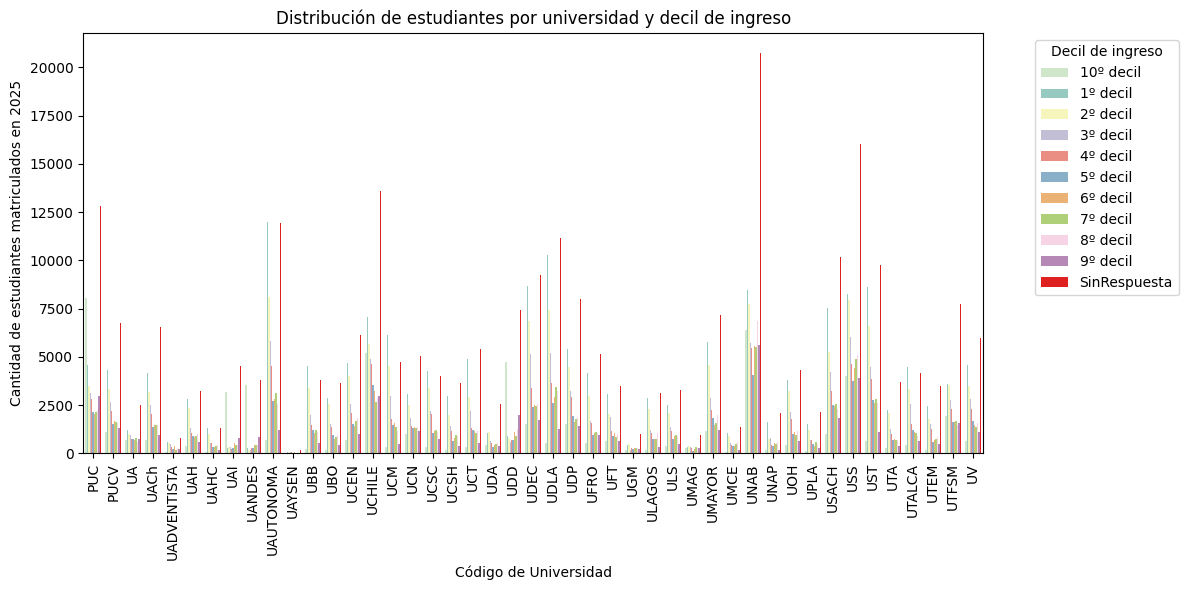

In [17]:
df_2024_Ingreso_Percapita[["CODIGO_UNIV",'Ingreso_Decil']]
#df_2025_Ingreso_Percapita["CODIGO_UNIV"].unique()

palette = {
    "1º decil": "#8dd3c7",
    "2º decil": "#ffffb3",
    "3º decil": "#bebada",
    "4º decil": "#fb8072",
    "5º decil": "#80b1d3",
    "6º decil": "#fdb462",
    "7º decil": "#b3de69",
    "8º decil": "#fccde5",
    "9º decil": "#bc80bd",
    "10º decil": "#ccebc5",   # verde claro
    "SinRespuesta": "#ff0000" # rojo fuerte para destacar
}

conteo = (df_2024_Ingreso_Percapita
          .groupby(["Codigo_uni", "Ingreso_Decil"])
          .size()
          .reset_index(name="Cantidad"))

plt.figure(figsize=(12, 6))
sns.barplot(data=conteo, x="Codigo_uni", y="Cantidad", hue="Ingreso_Decil", palette=palette)

plt.title("Distribución de estudiantes por universidad y decil de ingreso")
plt.xlabel("Código de Universidad")
plt.ylabel("Cantidad de estudiantes matriculados en 2025")
plt.xticks(rotation=90)
plt.legend(title="Decil de ingreso", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [18]:
correlacion = df_2024[["PTJE_POND", "INGRESO_PERCAPITA_GRUPO_FA"]].corr()
correlacion

,PTJE_POND,INGRESO_PERCAPITA_GRUPO_FA
PTJE_POND,1.000000,0.006733
INGRESO_PERCAPITA_GRUPO_FA,0.006733,1.000000


### **5) ¿Varía la cantidad de postulantes según el tipo de establecimiento?**

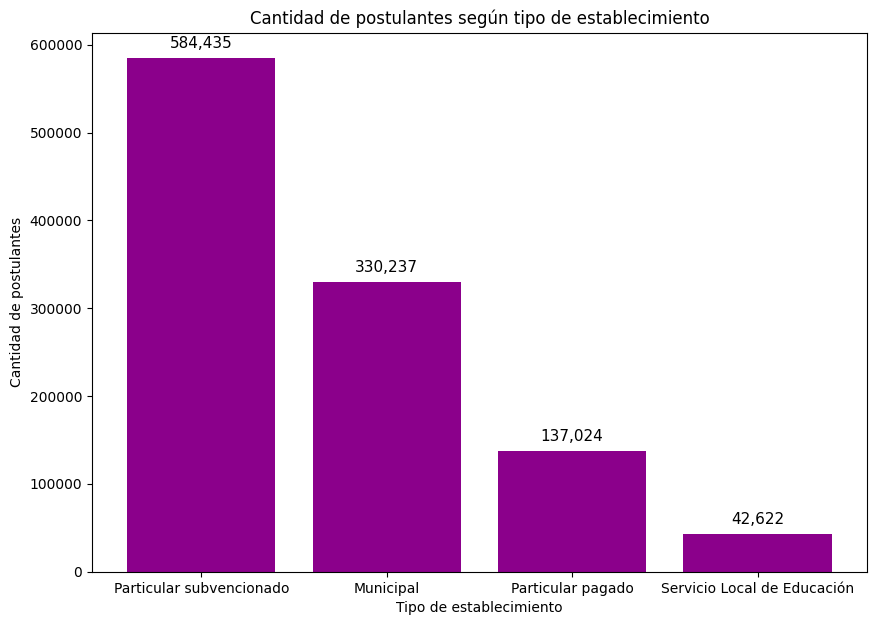

In [19]:
# primero, agrupo el df segun el tipo de colegio (uso la columna que creé anteriormente)
# luego, cuento cuantos estudiantes hay en cada uno
# soo basicamente ahi estoy obteniendo la cant de postulantes
postulantes = (df_2024.groupby("TIPO_COLEGIO")["ID_aux"].count()
    .reset_index(name="NUM_POSTULANTES").sort_values("NUM_POSTULANTES", ascending=False))
# dps, guardo la info en una nueva columna "NUM_POSTULANTES" para graficarla
# aaaa y la ordeno desde el tipo de colegio con mas postulantes al que tiene menos

# defino el tamaño del grafico y sus caracteristicas (de barras)
plt.figure(figsize=(10, 7))
plt.bar(postulantes["TIPO_COLEGIO"], postulantes["NUM_POSTULANTES"], color="darkmagenta")
# asigno el titulo del grafico y el de los ejes (x, y)
plt.title("Cantidad de postulantes según tipo de establecimiento")
plt.xlabel("Tipo de establecimiento")
plt.ylabel("Cantidad de postulantes")
plt.xticks(rotation=0)
# finalmente, agrego la cant encima de cada barra
for i, val in enumerate(postulantes["NUM_POSTULANTES"]):
    plt.text(i, val + max(postulantes["NUM_POSTULANTES"])*0.02,
            f"{val:,}", ha="center", fontsize=11)
plt.show() # muestro el grafico

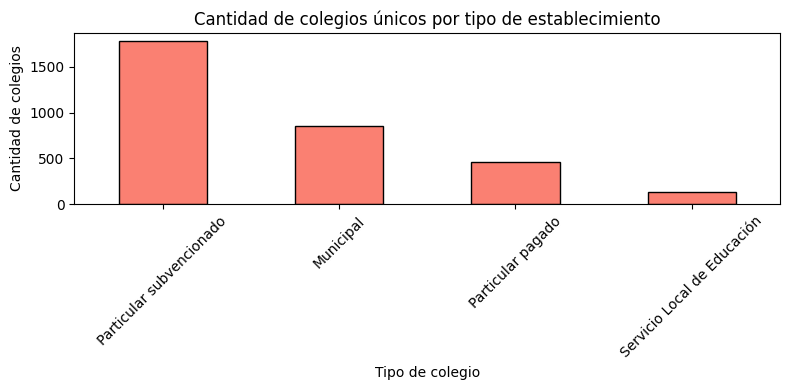

In [20]:
df_2024_copy = df_2024.copy()
colegios_unicos = df_2024_copy.drop_duplicates(subset="RBD_x")
conteo_colegios = colegios_unicos["TIPO_COLEGIO"].value_counts()

plt.figure(figsize=(8, 4))
conteo_colegios.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Cantidad de colegios únicos por tipo de establecimiento")
plt.xlabel("Tipo de colegio")
plt.ylabel("Cantidad de colegios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


analisis


---

# *Resultados*



---

# *¿Que podria salir mal?*

Si bien nuestro análisis confirma la grave desigualdad educativa en Chile, es crucial entender sus límites para no sacar conclusiones equivocadas:

- Los datos no son 100% reales para todo, Trabajamos con datos simulados que imitan los patrones estadísticos originales, por lo que las cifras son representativas, pero no exactas.

- Faltan piezas claves a la hora de concluir, no pudimos incluir información fundamental como la educación de los padres, el acceso a preuniversitarios o la infraestructura de los colegios. Esto significa que los factores de desigualdad podrían ser aún más complejos de lo que mostramos.

- Correlación pero no Causalidad, nuestros modelos muestran asociaciones muy fuertes, quienes pueden llegara  tener exito, pero no prueban la causa y efecto definitiva. No podemos decir que un factor causa el bajo rendimiento, solo que están fuertemente ligados.

- No muestra todas las feechas, el estudio se basa en datos recientes (2023-2025). Cualquier futura reforma educativa podría cambiar estos patrones, por lo que el análisis necesita ser actualizado constantemente.

En resumen: la evidencia de la brecha es sólida, pero debemos usarla con responsabilidad ética, recordando que los modelos simplifican la realidad y que las trayectorias individuales son mucho más ricas y complejas que cualquier estadística.

---

# *Conclusión*

En esencia, este análisis de datos nos arroja una verdad difícil de ignorar, que la educación en Chile no está cumpliendo su promesa de ser un motor de movilidad social.

Los números nos confirman que en nuestro sistema, el destino académico está peligrosamente atado a la billetera de los padres y al tipo de colegio al que asististe, mucho más que a tu talento o esfuerzo.

Hemos cuantificado que la diferencia entre un colegio privado y uno municipal no es un pequeño tropiezo, es un abismo estructural que predice, con demasiada exactitud, quién podrá acceder a la educación superior y quién no.

En términos humanos, esto significa que mientras un joven en un colegio pagado tiene el camino pavimentado y la meta casi garantizada, un estudiante igualmente brillante en un contexto vulnerable tiene que escalar una montaña de obstáculos solo para llegar a la línea de partida.

La desigualdad educativa no es una coincidencia, es un diseño. Este sistema, por más programas valiosos que tenga, sigue siendo un espejo que reproduce las profundas diferencias socioeconómicas del país.

Nuestra reflexión final es un llamado a la acción.

Los datos son claros, pero solo la voluntad política y una reforma estructural profunda podrán transformar la educación de un privilegio determinado por el origen a un derecho real para todos.